In [1]:
'''
Here as in our finding we found that amitosis can lower the Soma Mutation rate, we further want to investigate which part of the
genome that makes the difference (fitness-affecting loci or the Mu-controller loci?) under amitosis

We decoupled the division of fitness-affecting loci and Mu-controller loci:
- Fitness-affecting loci divided by amitosis vs Mu-controller loci divided by mitosis
- Fitness-affecting loci divided by mitosis vs Mu-controller loci divided by amitosis


And compared the new results with our previous findings on both types of loci divided by amitosis and both types of loci divided
by mitosis.

'''

'\nHere as in our finding we found that amitosis can lower the Soma Mutation rate, we further want to investigate which part of the\ngenome that makes the difference (fitness-affecting loci or the Mu-controller loci?) under amitosis\n\nWe decoupled the division of fitness-affecting loci and Mu-controller loci:\n- Fitness-affecting loci divided by amitosis vs Mu-controller loci divided by mitosis\n- Fitness-affecting loci divided by mitosis vs Mu-controller loci divided by amitosis\n\n\nAnd compared the new results with our previous findings on both types of loci divided by amitosis and both types of loci divided\nby mitosis.\n\n'

In [1]:
from __future__ import division
import numpy as np
from scipy import stats
import scipy.spatial as spa
import numpy.random as rnd
import copy
import time
import pandas as pd
import math
import pickle
import seaborn as sns
import os

In [2]:
def get_data1(file_list):
    
    total_fit_mean = []
    total_fit_std = []
    
    total_soma_mu_mean = []
    total_soma_mu_std = []

    total_germ_mu_mean = []
    total_germ_mu_std = []
    
    total_soma_genomic_mu_mean = []
    total_soma_genomic_mu_std = []    
    
    total_germ_genomic_mu_mean = []
    total_germ_genomic_mu_std = []  
    
    
    for i in file_list:
        f = pd.read_csv(i,dtype=str)
    
        fit_mean = []
        fit_std = []
    
        soma_mu_mean = []
        soma_mu_std = []
        
        germ_mu_mean = []
        germ_mu_std = []        
        
        soma_genomic_mu_mean = []
        soma_genomic_mu_std = []
        
        germ_genomic_mu_mean = []
        germ_genomic_mu_std = []   
        
        
        fit_mean.extend(list(pd.Series(f.PopMeanFit_Mean,dtype=float)))
        fit_std.extend(list(pd.Series(f.PopMeanFit_STD,dtype=float)))
    
        soma_mu_mean.extend(list(pd.Series(f.SomaMu_Mean,dtype=float)))
        soma_mu_std.extend(list(pd.Series(f.SomaMu_Std,dtype=float)))
        
        germ_mu_mean.extend(list(pd.Series(f.GermMu_Mean,dtype=float)))
        germ_mu_std.extend(list(pd.Series(f.GermMu_Std,dtype=float)))   
        
        soma_genomic_mu_mean.extend(list(pd.Series(f.SomaGenomicMu_Mean,dtype=float)))
        soma_genomic_mu_std.extend(list(pd.Series(f.SomaGenomicMu_Std,dtype=float)))
        
        germ_genomic_mu_mean.extend(list(pd.Series(f.GermGenomicMu_Mean,dtype=float)))
        germ_genomic_mu_std.extend(list(pd.Series(f.GermGenomicMu_Std,dtype=float)))        
        
        
        
        total_fit_mean.append(fit_mean)
        total_fit_std.append(fit_std)
    
        total_soma_mu_mean.append(soma_mu_mean)
        total_soma_mu_std.append(soma_mu_std)  
        
        total_germ_mu_mean.append(germ_mu_mean)
        total_germ_mu_std.append(germ_mu_std)    

        
        total_soma_genomic_mu_mean.append(soma_genomic_mu_mean)
        total_soma_genomic_mu_std.append(soma_genomic_mu_std)  
        
        total_germ_genomic_mu_mean.append(germ_genomic_mu_mean)
        total_germ_genomic_mu_std.append(germ_genomic_mu_std) 
        
        
        
    return total_fit_mean, total_fit_std, total_soma_mu_mean, total_soma_mu_std, \
total_germ_mu_mean, total_germ_mu_std, total_soma_genomic_mu_mean, total_soma_genomic_mu_std, \
total_germ_genomic_mu_mean, total_germ_genomic_mu_std

## Dele Only_N = 2K_Amito and Mito for both types of loci

In [22]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20190910_Evolution of Mu Rate_10 Upper and 10 Lower Ctrl_Revised\Data\2. Eff = 0.9_Lower Mu = 0.002 and Upper Mu = 0.01\1. Dele Only\N2K")

In [23]:
og_fit_file = ['Fit_Amito_N2K_DeleOnly_UP01LW002_MuEvo_190910R2.csv', 'Fit_Mito_N2K_DeleOnly_UP01LW002_MuEvo_190910R2.csv']

og = get_data1(og_fit_file)

og_fit_mean =og[0]
og_fit_std = og[1]

og_sm_mu_mean = og[2]
og_sm_mu_std = og[3]

og_gm_mu_mean = og[4]
og_gm_mu_std = og[5]

og_sm_genomic_mu_mean = og[6]
og_sm_genomic_mu_std = og[7]

og_gm_genomic_mu_mean = og[8]
og_gm_genomic_mu_std = og[9]

In [44]:
print 'Both Amito MAC Mu', og_sm_mu_mean[0][-1]/(0.1/45/100), og_sm_mu_mean[0][-1]/(0.1/45/100)-1.98*og_sm_mu_std[0][-1]/10/(0.1/45/100), og_sm_mu_mean[0][-1]/(0.1/45/100)+1.98*og_sm_mu_std[0][-1]/10/(0.1/45/100)
print 'Both Amito MIC Mu', og_gm_mu_mean[0][-1]/(0.1/45/100), og_gm_mu_mean[0][-1]/(0.1/45/100)-1.98*og_gm_mu_std[0][-1]/10/(0.1/45/100), og_gm_mu_mean[0][-1]/(0.1/45/100)+1.98*og_gm_mu_std[0][-1]/10/(0.1/45/100)

dele_og_sm_mu_mean = [og_sm_mu_mean[0][-1]/(0.1/45/100)]+[og_sm_mu_mean[1][-1]/(0.1/45/100)]
dele_og_sm_mu_std = [og_sm_mu_std[0][-1]/(0.1/45/100)]+[og_sm_mu_std[1][-1]/(0.1/45/100)]

dele_og_gm_mu_mean = [og_gm_mu_mean[0][-1]/(0.1/45/100)]+[og_gm_mu_mean[1][-1]/(0.1/45/100)]
dele_og_gm_mu_std = [og_gm_mu_std[0][-1]/(0.1/45/100)]+[og_gm_mu_std[1][-1]/(0.1/45/100)]

Both Amito MAC Mu 0.091731708836 0.0842148120805 0.0992486055915
Both Amito MIC Mu 1.22145128136 1.09577131682 1.3471312459


In [25]:
print 'Both Mito MAC Mu', og_sm_mu_mean[1][-1]/(0.1/45/100), og_sm_mu_mean[1][-1]/(0.1/45/100)-1.98*og_sm_mu_std[1][-1]/10/(0.1/45/100), og_sm_mu_mean[1][-1]/(0.1/45/100)+1.98*og_sm_mu_std[1][-1]/10/(0.1/45/100)
print 'Both Mito MIC Mu', og_gm_mu_mean[1][-1]/(0.1/45/100), og_gm_mu_mean[1][-1]/(0.1/45/100)-1.98*og_gm_mu_std[1][-1]/10/(0.1/45/100), og_gm_mu_mean[1][-1]/(0.1/45/100)+1.98*og_gm_mu_std[1][-1]/10/(0.1/45/100)

Both Mito MAC Mu 3.12624275382 2.97585547518 3.27663003247
Both Mito MIC Mu 6.83279387696 6.48119341513 7.18439433878


## Dele Only_N = 2K_Decoupled Fitness loci and Ctrl Loci

In [26]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20190910_Evolution of Mu Rate_10 Upper and 10 Lower Ctrl_Revised\Data\2.1. Fit Loci Amito Ctrl Mito and Fit Loci Mito Ctrl Amito\1. Dele Only\N2K")

In [27]:
rv_fit_file = ['Fit_FitAmito_CtrlMito_N2K_DeleOnly_UP01LW002_MuEvo_191002R2.csv','Fit_FitMito_CtrlAmito_N2K_DeleOnly_UP01LW002_MuEvo_191002R2.csv' ]

rv = get_data1(rv_fit_file)

rv_fit_mean =rv[0]
rv_fit_std = rv[1]

rv_sm_mu_mean = rv[2]
rv_sm_mu_std = rv[3]

rv_gm_mu_mean = rv[4]
rv_gm_mu_std = rv[5]

rv_sm_genomic_mu_mean = rv[6]
rv_sm_genomic_mu_std = rv[7]

rv_gm_genomic_mu_mean = rv[8]
rv_gm_genomic_mu_std = rv[9]

In [28]:
print 'FitAmito ModMito MAC Mu', rv_sm_mu_mean[0][-1]/(0.1/45/100), rv_sm_mu_mean[0][-1]/(0.1/45/100)-1.98*rv_sm_mu_std[0][-1]/10/(0.1/45/100), rv_sm_mu_mean[0][-1]/(0.1/45/100)+1.98*rv_sm_mu_std[0][-1]/10/(0.1/45/100)
print 'FitAmito ModMito MIC Mu', rv_gm_mu_mean[0][-1]/(0.1/45/100), rv_gm_mu_mean[0][-1]/(0.1/45/100)-1.98*rv_gm_mu_std[0][-1]/10/(0.1/45/100), rv_gm_mu_mean[0][-1]/(0.1/45/100)+1.98*rv_gm_mu_std[0][-1]/10/(0.1/45/100)

FitAmito ModMito MAC Mu 3.05614441718 2.92541830531 3.18687052905
FitAmito ModMito MIC Mu 6.61112938926 6.30615298227 6.91610579625


In [45]:
print 'FitMito ModAmito MAC Mu', rv_sm_mu_mean[1][-1]/(0.1/45/100), rv_sm_mu_mean[1][-1]/(0.1/45/100)-1.98*rv_sm_mu_std[1][-1]/10/(0.1/45/100), rv_sm_mu_mean[1][-1]/(0.1/45/100)+1.98*rv_sm_mu_std[1][-1]/10/(0.1/45/100)
print 'FitMito ModAmito MIC Mu', rv_gm_mu_mean[1][-1]/(0.1/45/100), rv_gm_mu_mean[1][-1]/(0.1/45/100)-1.98*rv_gm_mu_std[1][-1]/10/(0.1/45/100), rv_gm_mu_mean[1][-1]/(0.1/45/100)+1.98*rv_gm_mu_std[1][-1]/10/(0.1/45/100)

dele_rv_sm_mu_mean = [rv_sm_mu_mean[0][-1]/(0.1/45/100)]+[rv_sm_mu_mean[1][-1]/(0.1/45/100)]
dele_rv_sm_mu_std = [rv_sm_mu_std[0][-1]/(0.1/45/100)]+[rv_sm_mu_std[1][-1]/(0.1/45/100)]

dele_rv_gm_mu_mean = [rv_gm_mu_mean[0][-1]/(0.1/45/100)]+[rv_gm_mu_mean[1][-1]/(0.1/45/100)]
dele_rv_gm_mu_std = [rv_gm_mu_std[0][-1]/(0.1/45/100)]+[rv_gm_mu_std[1][-1]/(0.1/45/100)]

FitMito ModAmito MAC Mu 0.0701622917 0.0613292396116 0.0789953437884
FitMito ModAmito MIC Mu 1.28491508872 1.14581084838 1.42401932907


In [46]:
dele_rv_sm_mu_mean

[3.0561444171795187, 0.070162291699999976]

## 1% Bene_N = 2K_Amito and Mito for both types of loci

In [30]:
def get_data2(file_list):
    
    total_fit_mean = []
    total_fit_std = []
    
    total_soma_mu_bene_mean = []
    total_soma_mu_bene_std = []

    total_soma_mu_dele_mean = []
    total_soma_mu_dele_std = []
    
    total_germ_mu_bene_mean = []
    total_germ_mu_bene_std = []

    total_germ_mu_dele_mean = []
    total_germ_mu_dele_std = []  
    
    for i in file_list:
        f = pd.read_csv(i,dtype=str)
    
        fit_mean = []
        fit_std = []
    
        soma_mu_bene_mean = []
        soma_mu_bene_std = []

        soma_mu_dele_mean = []
        soma_mu_dele_std = []
        
        germ_mu_bene_mean = []
        germ_mu_bene_std = []        
         
        germ_mu_dele_mean = []
        germ_mu_dele_std = []             
        
        fit_mean.extend(list(pd.Series(f.PopMeanFit_Mean,dtype=float)))
        fit_std.extend(list(pd.Series(f.PopMeanFit_STD,dtype=float)))
    
        soma_mu_bene_mean.extend(list(pd.Series(f.SomaMu_Bene_Mean,dtype=float)))
        soma_mu_bene_std.extend(list(pd.Series(f.SomaMu_Bene_Std,dtype=float)))

        soma_mu_dele_mean.extend(list(pd.Series(f.SomaMu_Dele_Mean,dtype=float)))
        soma_mu_dele_std.extend(list(pd.Series(f.SomaMu_Dele_Std,dtype=float)))
        
        
        germ_mu_bene_mean.extend(list(pd.Series(f.GermMu_Bene_Mean,dtype=float)))
        germ_mu_bene_std.extend(list(pd.Series(f.GermMu_Bene_Std,dtype=float)))

        germ_mu_dele_mean.extend(list(pd.Series(f.GermMu_Dele_Mean,dtype=float)))
        germ_mu_dele_std.extend(list(pd.Series(f.GermMu_Dele_Std,dtype=float)))
        
        
        total_fit_mean.append(fit_mean)
        total_fit_std.append(fit_std)
    
        total_soma_mu_bene_mean.append(soma_mu_bene_mean)
        total_soma_mu_bene_std.append(soma_mu_bene_std)  

        total_soma_mu_dele_mean.append(soma_mu_dele_mean)
        total_soma_mu_dele_std.append(soma_mu_dele_std)
        
        total_germ_mu_bene_mean.append(germ_mu_bene_mean)
        total_germ_mu_bene_std.append(germ_mu_bene_std)    

        total_germ_mu_dele_mean.append(germ_mu_dele_mean)
        total_germ_mu_dele_std.append(germ_mu_dele_std)
        
        
    return total_fit_mean, total_fit_std, total_soma_mu_bene_mean, total_soma_mu_bene_std, \
total_soma_mu_dele_mean, total_soma_mu_dele_std, total_germ_mu_bene_mean, total_germ_mu_bene_std, \
total_germ_mu_dele_mean, total_germ_mu_dele_std

In [48]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20190910_Evolution of Mu Rate_10 Upper and 10 Lower Ctrl_Revised\Data\2. Eff = 0.9_Lower Mu = 0.002 and Upper Mu = 0.01\2. 1% Bene\N2K\SP")

In [49]:
bene_og_fit_file = ['Fit_Amito_N2K_Bene01_UP01LW002_MuEvo_190910R2.csv', 'Fit_Mito_N2K_Bene01_UP01LW002_MuEvo_190910R2.csv']

bene_og = get_data2(bene_og_fit_file)

bene_og_fit_mean =bene_og[0]
bene_og_fit_std = bene_og[1]

bene_og_sm_mu_bene_mean = bene_og[2]
bene_og_sm_mu_bene_std = bene_og[3]

bene_og_sm_mu_dele_mean = bene_og[4]
bene_og_sm_mu_dele_std = bene_og[5]

bene_og_gm_mu_bene_mean = bene_og[6]
bene_og_gm_mu_bene_std = bene_og[7]

bene_og_gm_mu_dele_mean = bene_og[8]
bene_og_gm_mu_dele_std = bene_og[9]

In [50]:
bene_og_sm_mu_dele_mean = [bene_og_sm_mu_dele_mean[0][-1]/(0.1/45/100)]+[bene_og_sm_mu_dele_mean[1][-1]/(0.1/45/100)]
bene_og_sm_mu_dele_std = [bene_og_sm_mu_dele_std[0][-1]/(0.1/45/100)]+[bene_og_sm_mu_dele_std[1][-1]/(0.1/45/100)]

bene_og_gm_mu_dele_mean = [bene_og_gm_mu_dele_mean[0][-1]/(0.1/45/100)]+[bene_og_gm_mu_dele_mean[1][-1]/(0.1/45/100)]
bene_og_gm_mu_dele_std = [bene_og_gm_mu_dele_std[0][-1]/(0.1/45/100)]+[bene_og_gm_mu_dele_std[1][-1]/(0.1/45/100)]

## 1% Bene_N = 2K_Decoupled Fitness loci and Ctrl Loci

In [51]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20190910_Evolution of Mu Rate_10 Upper and 10 Lower Ctrl_Revised\Data\2.1. Fit Loci Amito Ctrl Mito and Fit Loci Mito Ctrl Amito\2. 1% Bene\N2K\SP")

In [52]:
bene_rv_fit_file = ['Fit_FitAmito_CtrlMito_N2K_Bene01_UP01LW002_MuEvo_191002R2.csv','Fit_FitMito_CtrlAmito_N2K_Bene01_UP01LW002_MuEvo_191002R2.csv' ]

bene_rv = get_data2(bene_rv_fit_file)

bene_rv_fit_mean =bene_rv[0]
bene_rv_fit_std = bene_rv[1]

bene_rv_sm_mu_bene_mean = bene_rv[2]
bene_rv_sm_mu_bene_std = bene_rv[3]

bene_rv_sm_mu_dele_mean = bene_rv[4]
bene_rv_sm_mu_dele_std = bene_rv[5]

bene_rv_gm_mu_bene_mean = bene_rv[6]
bene_rv_gm_mu_bene_std = bene_rv[7]

bene_rv_gm_mu_dele_mean = bene_rv[8]
bene_rv_gm_mu_dele_std = bene_rv[9]

In [53]:
bene_rv_sm_mu_dele_mean = [bene_rv_sm_mu_dele_mean[0][-1]/(0.1/45/100)]+[bene_rv_sm_mu_dele_mean[1][-1]/(0.1/45/100)]
bene_rv_sm_mu_dele_std = [bene_rv_sm_mu_dele_std[0][-1]/(0.1/45/100)]+[bene_rv_sm_mu_dele_std[1][-1]/(0.1/45/100)]

bene_rv_gm_mu_dele_mean = [bene_rv_gm_mu_dele_mean[0][-1]/(0.1/45/100)]+[bene_rv_gm_mu_dele_mean[1][-1]/(0.1/45/100)]
bene_rv_gm_mu_dele_std = [bene_rv_gm_mu_dele_std[0][-1]/(0.1/45/100)]+[bene_rv_gm_mu_dele_std[1][-1]/(0.1/45/100)]

In [54]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 36})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(6)
    ax.spines['bottom'].set_linewidth(6)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=20, width=6, direction='out', pad=50, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=20, width=6, direction='out', pad=50, colors='black')

In [55]:
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
import pickle
%matplotlib inline

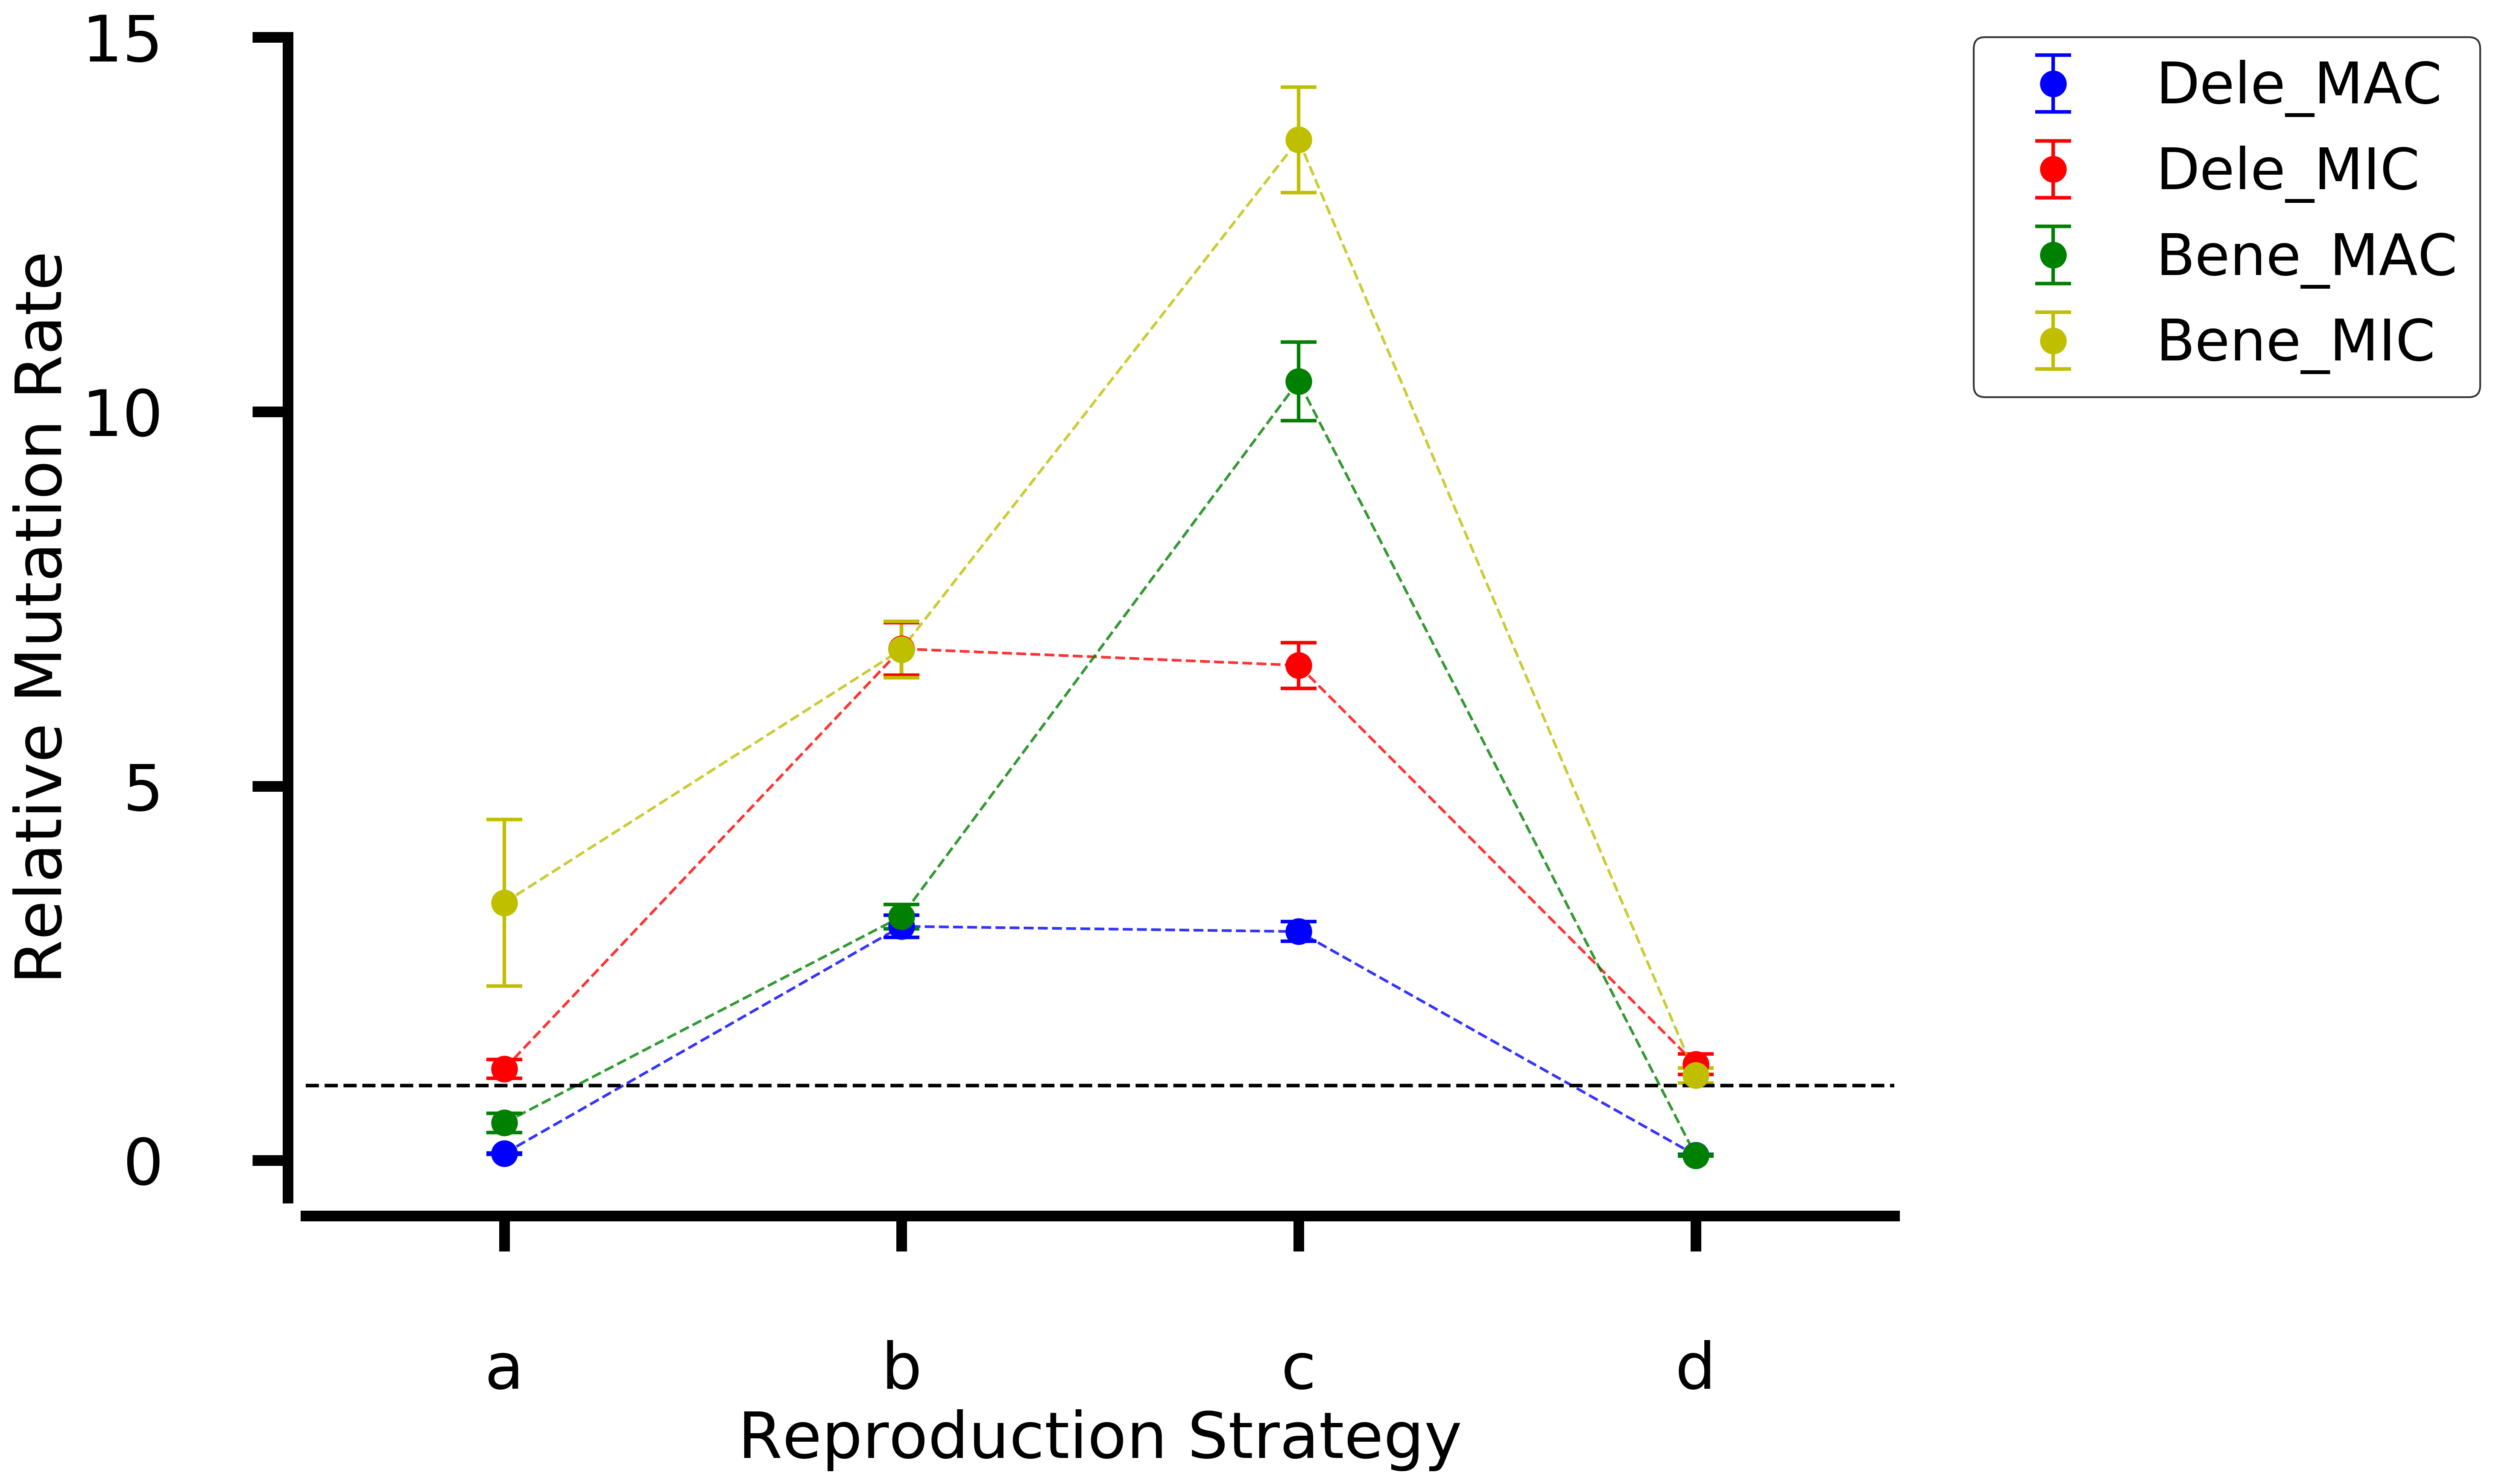

In [77]:
fig = plt.figure(figsize=(16, 12), dpi = 300)
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_ylim(-0.5, 15)
ax.set_xlim(0.5,4.5)


x = [1,2, 3, 4]

a = dele_og_sm_mu_mean+ dele_rv_sm_mu_mean
error_a = 1.98* np.array(dele_og_sm_mu_std+ dele_rv_sm_mu_std)/((100)**0.5)


b = dele_og_gm_mu_mean+ dele_rv_gm_mu_mean
error_b = 1.98* np.array(dele_og_gm_mu_std+ dele_rv_gm_mu_std)/((100)**0.5)


c = bene_og_sm_mu_dele_mean+ bene_rv_sm_mu_dele_mean
error_c = 1.98* np.array(bene_og_sm_mu_dele_std+ bene_rv_sm_mu_dele_std)/((100)**0.5)


d = bene_og_gm_mu_dele_mean+ bene_rv_gm_mu_dele_mean
error_d = 1.98* np.array(bene_og_gm_mu_dele_std+ bene_rv_gm_mu_dele_std)/((100)**0.5)


ax.set_xlabel('Reproduction Strategy', fontsize =36)
ax.set_ylabel('Relative Mutation Rate', fontsize =36)


ax.errorbar(x, a, yerr = error_a, label = 'Dele_MAC', fmt='o', color = 'b', markersize =14, lw=2, capsize=10, capthick=2)
ax.plot(x,a, ls = '--', color = 'b', alpha = 0.8)

ax.errorbar(x, b, yerr = error_b, label = 'Dele_MIC', fmt='o',color = 'r', markersize =14, lw=2, capsize=10, capthick=2)
ax.plot(x,b,ls = '--', color = 'r', alpha = 0.8)

ax.errorbar(x, c, yerr = error_c, label = 'Bene_MAC', fmt='o', color = 'g', markersize =14, lw=2, capsize=10, capthick=2)
ax.plot(x,c, ls = '--', color = 'g', alpha = 0.8)

ax.errorbar(x, d, yerr = error_d, label = 'Bene_MIC', fmt='o',color = 'y', markersize =14, lw=2, capsize=10, capthick=2)
ax.plot(x,d,ls = '--', color = 'y', alpha = 0.8)




plt.axhline(y=1, linewidth=2.0, color ='k',ls ='dashed')

ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =32)
frame = legend.get_frame()
# frame.set_framecolor('black')
frame.set_edgecolor('black')

# extraticks=[0.45, 0.95]
# ax.set_yticks(list(ax.get_yticks()) + extraticks)

# ax.set_ylim(0.4, 1)

ax.set_xticks([1, 2, 3, 4]) # choose which x locations to have ticks
# ax.set_xticklabels(['Both Amitosis', 'Both Mitosis', 'Fit Amito_Mod Mito', 'Fit Mito_Mod Amito'], rotation = 270) # set the labels to display at those ticks
ax.set_xticklabels(['a', 'b', 'c', 'd']) # set the labels to display at those ticks


ax.set_yticks([0, 5, 10, 15]) # choose which x locations to have ticks
# ax.set_xticklabels(['Both Amitosis', 'Both Mitosis', 'Fit Amito_Mod Mito', 'Fit Mito_Mod Amito'], rotation = 270) # set the labels to display at those ticks
ax.set_yticklabels([0, 5, 10, 15]) # set the labels to display at those ticks


# plt.legend(loc='upper right', frameon=False, prop={'size':29})


plt.show()